## 2 Solow model

In [33]:
from types import SimpleNamespace
from scipy import optimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from SolowModel import SolowModelClass

model = SolowModelClass() #Model with default calibrations
par = model.par #Stored default model parameters
t = np.arange(par.T) #Ti,e vector from 0 to T-1. Since T=100, we have 100 observed time periods

#copy of original simulation results
def copy_sim(sim):
    return SimpleNamespace(**{name: np.asarray(getattr(sim,name)).copy()
                              for name in ('s','k','y','i','c')})

#Standard three-panel figure for assignment
def plot_paths(paths,title):
    fig,axes = plt.subplots(1,3,figsize=(15,4))
    for label,sim in paths.items():
        axes[0].plot(t,sim.s,label=label)
        axes[1].plot(t,sim.k,label=label)
        axes[2].plot(t,sim.c,label=label)
    for ax,ylabel in zip(axes,[r'Savings rate, $s_t$',r'Capital, $k_t$',r'Consumption, $c_t$']):
        ax.set(xlabel='Period, $t$',ylabel=ylabel)
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

**2.1**

2.1.1 STEADY STATE


,value
analytical k*,0.760726
numerical k*,0.760726
y*,0.912871
c*,0.684653


2.1.2 SIMULATION


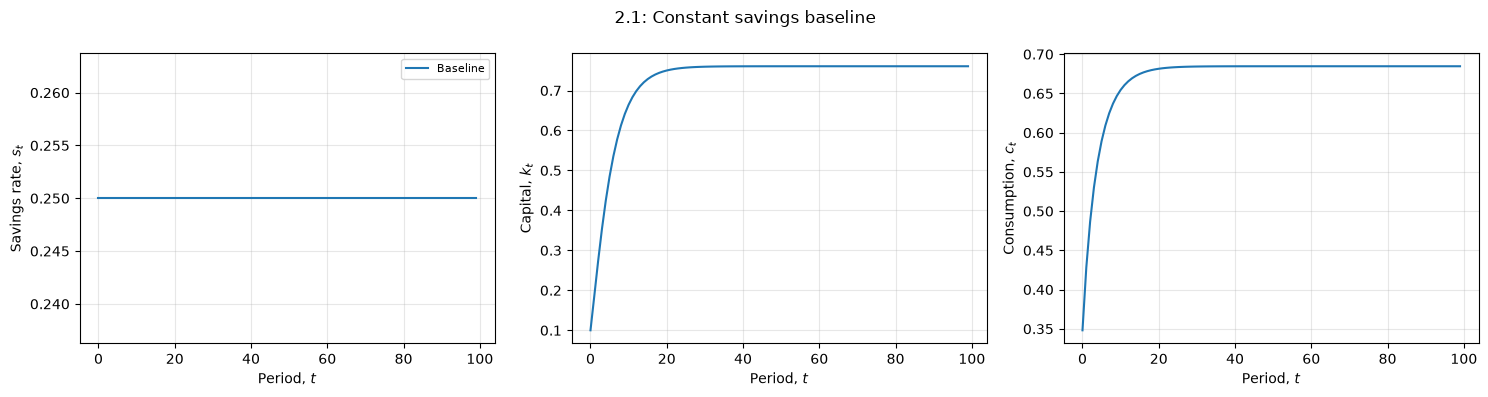

c_0=0.348119
c_T-1=0.684653
k_T-1=0.760726


In [34]:
#Steady state
k_star,y_star,c_star = model.steady_state() #solves analytically steady state "formula"
k_star_num = model.solve_steady_state() #solves numerically using (4) and constant savings rate

#Baseline results
print('2.1.1 STEADY STATE')
display(pd.Series({'analytical k*':k_star,'numerical k*':k_star_num,
                   'y*':y_star,'c*':c_star},name='value').to_frame())

print('2.1.2 SIMULATION')
baseline = copy_sim(model.simulate(par.s_bar))
plot_paths({'Baseline':baseline},'2.1: Constant savings baseline')

print(f'c_0={baseline.c[0]:.6f}')
print(f'c_T-1={baseline.c[-1]:.6f}')
print(f'k_T-1={baseline.k[-1]:.6f}')

#Tests with known answers
#Test 1: An economy beginning at the steady state must remain there
sim_ss = copy_sim(model.simulate(par.s_bar, k0=k_star))

assert np.allclose(sim_ss.k, k_star), "Capital does not remain at the steady state"
assert np.allclose(sim_ss.y, y_star), "Output does not remain at the steady state"

#Test 2: With zero savings, there are no investments, hence, capital only changes through depreciation
sim_zero = copy_sim(model.simulate(0.0,k0=par.k0))
k_zero_expected = par.k0*(1-par.delta)**t #Capital path when the savings rate is zero

assert np.allclose(sim_zero.k, k_zero_expected), "Capital does not follow the expected depreciation path"
assert np.allclose(sim_zero.i,0.0), "Investment is not zero when the savings rate is zero"



The assertions are successful, meanimg the simulator tests pass


**2.2**

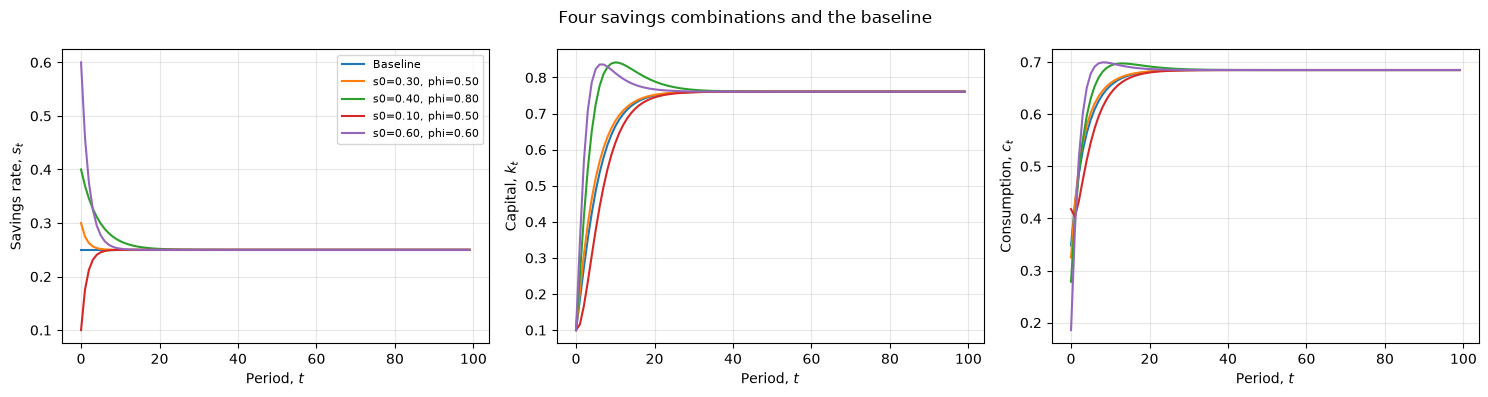

,k_{T-1}
Baseline,0.760726
"s0=0.30, phi=0.50",0.760726
"s0=0.40, phi=0.80",0.760726
"s0=0.10, phi=0.50",0.760726
"s0=0.60, phi=0.60",0.760726


In [ ]:
#Create paramester tuple combinations, (s0, phi)
combinations = [(0.30,0.50),(0.40,0.80),(0.10,0.50),(0.60,0.60)]

#Dictionary for simulations
paths = {'Baseline':baseline}

#Simulating the four combinations
for s0,phi in combinations:
    label = f's0={s0:.2f}, phi={phi:.2f}'
    paths[label] = copy_sim(model.simulate(model.s_path(s0,phi)))

#Plot
plot_paths(paths,'2.2: Four savings combinations and the baseline')

#Report of k_{T-1}
display(pd.Series({label:sim.k[-1] for label,sim in paths.items()},
                  name=r'k_{T-1}').to_frame())



All combinations approach the same terminal capital given by the baseline. This is due to all the simulations converging to the same long-run savings rate,  $\bar s$.

$s_0$ gives the starting savings rate. When it is above $\bar s$ (positive initial savings gap), which is the case for combination 1, 2, and 4, the economy invests more than the baseline early on, so capital and output grow faster at first. This comes at the cost of lower initial consumption, since a larger share of the output is saved rather than consumed. The opposite happens when $s_0$ is below the steady state $\bar s$.


$\phi$ is the persistence of the initial savings gap between the actual savings rate and the steady state. Therefore, the higher $\phi$ is, the longer the convergence takes, whereas a lower value means the initial savings gap disappears almost immediately, hence, the path will be close to the baseline throughout the convergence.

The initial savings gap only matters for the transition, as $\phi<1$ means that $s_t$ always converges towards $\bar s$.



**2.3**

In [36]:
#Baseline welfare
W_baseline = model.welfare(baseline.c)

#Table rows
rows = [{'Combination':'Baseline','W':W_baseline,'W - W_baseline':0.0}]

#Test all combinations
for label, sim in list(paths.items())[1:]:
    W = model.welfare(sim.c) #Calculates welfare
    rows.append({'Combination':label,'W':W,'W - W_baseline':W-W_baseline})

#Construct table
welfare_table = pd.DataFrame(rows).set_index('Combination')

display(welfare_table.style.format('{:.6f}'))



,W,W - W_baseline
Combination,,
Baseline,-3.994388,0.000000
"s0=0.30, phi=0.50",-3.985706,0.008682
"s0=0.40, phi=0.80",-4.091413,-0.097025
"s0=0.10, phi=0.50",-4.146018,-0.151630
"s0=0.60, phi=0.60",-4.340653,-0.346265


There is only one combination where the welfare is higher than the baseline: $(s_0,\phi)=(0.30,0.50)$. The combination has the mildest, and most short-lived deviation from baseline in all three panels, meaning it is most likely closest to the baseline at the least. 


Based on *2.2*, it would be reasonable to expect the combination $(s_0,\phi)=(0.10,0.50)$ to have the highest welfare, as welfare is based on utility from all consumption, with the largest weight on the current, and then a discounting of future consumption. However, this is not the case, as the initial capital is so low, making investments are very productive. Therefore, the early on under investing will  ultimately cost more in lost future consumption from gained output.

Hence, the initial small consumption loss in $(s_0,\phi)=(0.30,0.50)$ (which is followed by a larger consumption than the baseline), has less of an impact than the under-investment in capital. However, this ccan not be deduced from the panels from *2.2* alone.


**2.4**

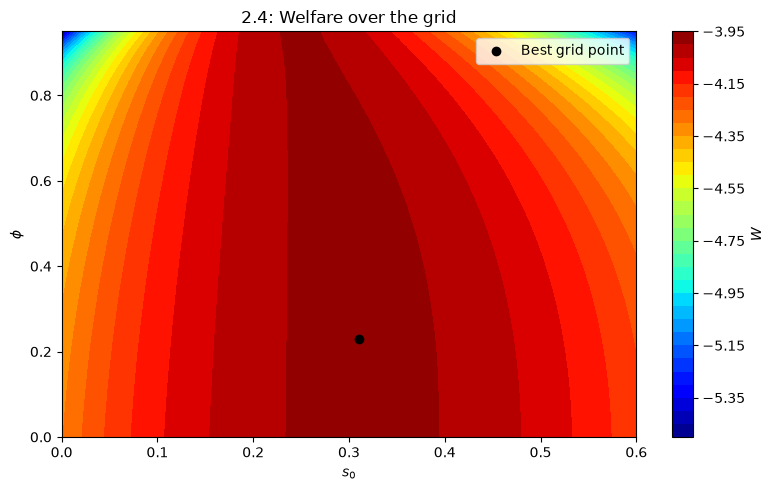

,s0,phi,W
Grid,0.310000,0.230000,-3.984306
Optimizer,0.311497,0.220771,-3.984300


Optimizer: True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


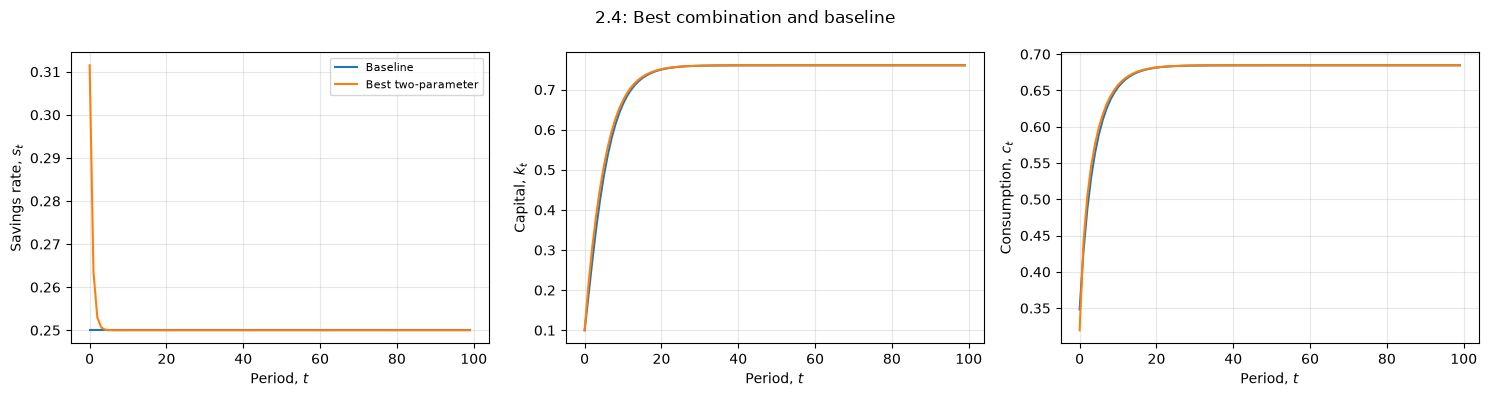

,$c_0$
Baseline,0.348119
Best two-parameter combination,0.319575


First period with c_t above baseline: 1


In [ ]:
#Create grid array and increments
s0_grid = np.linspace(0.0,0.60,61)
phi_grid = np.linspace(0.0,0.95,96)

W_grid = np.empty((phi_grid.size,s0_grid.size))

#Calculate welfare at every grid point
for i,phi in enumerate(phi_grid):
    for j,s0 in enumerate(s0_grid):
        W_grid[i,j] = model.evaluate(s0,phi)

#Find optimal on grid
i_best,j_best = np.unravel_index(np.argmax(W_grid),W_grid.shape)
grid_s0,grid_phi,grid_W = s0_grid[j_best],phi_grid[i_best],W_grid[i_best,j_best]


#Contour plot
fig,ax = plt.subplots(figsize=(8,5))
cs = ax.contourf(s0_grid,phi_grid,W_grid,levels=30,cmap=cm.jet)
ax.scatter(grid_s0,grid_phi,color='black',label='Best grid point')
ax.set(xlabel=r'$s_0$',ylabel=r'$\phi$',title='2.4: Welfare over the grid')
ax.legend(); fig.colorbar(cs,ax=ax,label='$W$'); fig.tight_layout(); plt.show()

#Numerical optimizatiom
result_two = optimize.minimize(lambda x:-model.evaluate(x[0],x[1]), #Negative welfare, as function finds minimum
    x0=[grid_s0,grid_phi],method='L-BFGS-B',bounds=((0,1),(0,0.999999)))

best_s0,best_phi = result_two.x
best_W_two = -result_two.fun
best_two = copy_sim(model.simulate(model.s_path(best_s0,best_phi)))

#Table for comparison
display(pd.DataFrame({'s0':[grid_s0,best_s0],'phi':[grid_phi,best_phi],
                      'W':[grid_W,best_W_two]},index=['Grid','Optimizer']).style.format('{:.6f}'))

print('Optimizer:',result_two.success,result_two.message) #checks that SciPy reports successful convergence

#Compare optimal and baseline path 
plot_paths({'Baseline':baseline,'Best two-parameter':best_two},'2.4: Best combination and baseline')
above = np.flatnonzero(best_two.c>baseline.c)
first_above = int(above[0]) if above.size else None


display(pd.DataFrame({r'c_0': [baseline.c[0], best_two.c[0]]}, index=['Baseline', 'Best two-parameter combination']).style.format('{:.6f}'))
print('First period with c_t above baseline:',first_above)


The two solutions achieve very similar results. However, the optimizer's is slightly better. This is as expected,as the grid only evaluates welfare on a finite, discrete set of points. The the numerical optimizer starts from that grid point and fine tunes even further. 

The best rule (two parameter combination) yields a slightly smaller $c_0$ than the baseline. This is already overtaken in $t=1$


**2.5**

In [ ]:
#Construct the new savings path
def s_path_three(s0,phi,s_inf):
    return s_inf+(s0-s_inf)*phi**t


def evaluate_three(x): 
    s0, phi, s_inf = x

    savings_path = s_path_three(s0, phi, s_inf)

    sim = model.simulate(savings_path)
    W = model.welfare(sim.c)

    return W


#Numerical optimization
result_three = optimize.minimize(lambda x:-evaluate_three(x),
    x0=[best_s0,best_phi,par.s_bar], #initial guesses
    method='L-BFGS-B',
    bounds=((0,1),(0,0.999999999),(0,1)))

#Optimal values
best_s0_three,best_phi_three,best_s_inf = result_three.x
best_W_three = -result_three.fun

#Simulating the best combination
best_three = copy_sim(model.simulate(s_path_three(*result_three.x)))

print('Optimizer results')
print(f's0={best_s0_three:.6f}, phi={best_phi_three:.6f}, s_inf={best_s_inf:.6f}')

print(f'W={best_W_three:.6f}')
print(f'Improvement from Q2.4: {best_W_three-best_W_two:.6f}')

print(f'k_T-1={best_three.k[-1]:.6f}')
print(f'Q2.1: k*={k_star:.6f}')
print(f'Change from Q2.1: {best_three.k[-1]-k_star:.6f}')

print('Optimizer:',result_three.success,result_three.message)


Optimizer results
s0=0.313859, phi=0.670773, s_inf=0.198944
W=-3.966965
Improvement from Q2.4: 0.017335
k_T-1=0.540026
Q2.1 k*=0.760726
Change from Q2.1: -0.220700
Optimizer: True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


The terminal capital is not the same as the original $k^*$. This is as to be expected, as $s_\infty$ is smaller than $\bar s$ (leads to less accumulation).  



**2.6**


We change the savings rule by adding random negative shocks, that is supposed to symbolize the unforseen circumstances that need to be fixed. This can be done to the two and three parameter saving rule. By adding negative shocks, they become

$$s_t^{\bar{s},shock}=\bar{s}+(s_0-\bar{s})\phi^t-d_t$$

$$s_t^{\infty,shock}=s_\infty+(s_0-s_\infty)\phi^t-d_t.$$

The shock can occur randomly in any period. Therefore, the shock term is given by

$$d_t=\phi d_{t-1}+\varepsilon_t=\sum_{j=0}^{t}\varepsilon_j\phi^{t-j},$$

where $\varepsilon_t=I_tu_t\phi^t$ is the small random shock, $I_t\sim\mathrm{Bernoulli}(0.05)$ is an indicator for whether a shock occurs, and $u_t\sim U(0.005,0.015)$ determines its size. The indicator equals one with 5% probability and zero otherwise, so there is not a shock in every period and multiple shocks can occur over the $T$ periods. Multiplication by $\phi^t$ makes new shocks smaller over time, while the term $\phi d_{t-1}$ makes shocks that have already occurred persist. Since $d_t$ is subtracted, every realized shock reduces current savings.

The code uses the optimized $(s_0,\phi)$ from Question 2.4 for the rule converging to $\bar{s}$, and the optimized $(s_0,\phi,s_\infty)$ from Question 2.5 for the alternative rule.


The reported welfare is the expected welfare,  which has been estimated as the average across 1,000 shock histories generated with seed 2026. The same random event and size draws are used for the $\bar{s}$ and $s_\infty$ rules, so that they are easy to compare.


In [53]:
#Shock parameters
shock_probability = 0.05
shock_min = 0.005
shock_max = 0.015
N_shock = 1000

def persistent_negative_shock(phi, event_draws, size_draws):
    #Shock indicator
    accidents = np.where(
        event_draws <= shock_probability, 
        size_draws*phi**t,
        0.0
    )

    #Shock persistence
    shock = np.empty(par.T)
    shock[0] = accidents[0] #d_0=e_0
    for period in range(1,par.T):
        shock[period] = phi*shock[period-1] + accidents[period]

    return shock


#Combine shocks with previous saving rules
def savings_rule_with_shocks(s0,phi,s_long,event_draws,size_draws):
    
    deterministic_s = s_long + (s0-s_long)*phi**t #s_long allowsit to be either either par.s_bar or best_s_inf

    shock = persistent_negative_shock(phi,event_draws,size_draws)

    #Create d_t
    shocked_s = np.clip(deterministic_s-shock,0.0,1.0) #unsure savings rate cannot be below 0 or above 1

    return shocked_s,deterministic_s,shock

#Random accidents for both versions (2.4 and 2.5)
rng = np.random.default_rng(2026)
event_draws = rng.random((N_shock,par.T)) #1000 different possible ways for shock occurence in the 100 periods
size_draws = rng.uniform(shock_min,shock_max,size=(N_shock,par.T))

#Welfare results for each type
W_shock_sbar = np.empty(N_shock)
W_shock_sinf = np.empty(N_shock)

#Simulate 1000 different shock histories over the periods
for n in range(N_shock):
    #Two-parameter rule
    s_shock_sbar,_,_ = savings_rule_with_shocks(
        best_s0,best_phi,par.s_bar,event_draws[n],size_draws[n]
    )
    W_shock_sbar[n] = model.welfare(model.simulate(s_shock_sbar).c)

    #Three-parameter rule
    s_shock_sinf,_,_ = savings_rule_with_shocks(
        best_s0_three,best_phi_three,best_s_inf,event_draws[n],size_draws[n]
    )
    W_shock_sinf[n] = model.welfare(model.simulate(s_shock_sinf).c)

#Welfare is expected welfare from 1000 simulations
W_shock_sbar_mean = W_shock_sbar.mean()
W_shock_sinf_mean = W_shock_sinf.mean()

welfare_comparison = pd.DataFrame(
    {
        'Welfare': [
            W_baseline,
            best_W_two,
            best_W_three,
            W_shock_sbar_mean,
            W_shock_sinf_mean
        ],
        'Std. dev. across shocks': [
            np.nan,
            np.nan,
            np.nan,
            W_shock_sbar.std(ddof=1),
            W_shock_sinf.std(ddof=1)
        ]
    },
    index=[
        '2.1 Baseline',
        '2.4 Best rule: long run s_bar',
        '2.5 Best rule: long run s_inf',
        '2.6 Negative shocks: long run s_bar',
        '2.6 Negative shocks: long run s_inf'
    ]
)

#Table of different welfare
display(
    welfare_comparison.style
        .format('{:.6f}',na_rep='-')
        .set_caption('Welfare with and without random negative savings shocks')
)




,Welfare,Std. dev. across shocks
2.1 Baseline,-3.994388,-
2.4 Best rule: long run s_bar,-3.984300,-
2.5 Best rule: long run s_inf,-3.966965,-
2.6 Negative shocks: long run s_bar,-3.984316,0.000075
2.6 Negative shocks: long run s_inf,-3.967008,0.000163


The expected welfare is smaller when the negative shocks are introduced. This is the case for the two- and three-parameter saving rules. The mechanism is similar to the one in *2.2*. Despite the consumption increasing (the consumer does not differentiate between "good" and "bad" consumption), the welfare does not increase as the negative effect on lost output (from under-investing in capital in any given period) is larger. The shocks are quite small, meaning that there is not a big difference in welfare. All in all, this addition does not beat the older versions.